<div style="background: #F0FAFF; border-radius: 3px; padding: 10px;">
<h1>Population Decoding of Visual Stimuli from Neural Activity</h1>

We record from a population of neurons in mouse visual cortex while the animal watches drifting
gratings. Each grating has an **orientation** (which direction it drifts) and a **temporal
frequency** (how fast it drifts). Our question: how well can we guess which grating was shown,
just by looking at the neurons' activity?

**What this notebook does, in order:**
1. Pick the recording session with the most neurons.
2. Look at how neurons respond to orientation and temporal frequency (separately).
3. Build a population decoder and compare several classifiers.
4. Run three follow-up experiments with the best classifier(s).
</div>

In [2]:
# @title Run to initialize Allen Brain Observatory on Colab {display-mode: "form" }

# run only once per runtime/session, and only if running in colab
# the runtime will need to restart after
%%capture
!apt install s3fs

!pip uninstall -y numpy pandas
!pip install git+https://github.com/AllenInstitute/AllenSDK@1bdca3ad884c3a5edea8236161424650603e6f29 "numpy == 1.26.4" "pandas == 2.3.0" "matplotlib > 3.8.0" "statsmodels >= 0.14.4"
import allensdk
print('allensdk imported successfully')

!mkdir -p /data/allen-brain-observatory/
!s3fs allen-brain-observatory /data/allen-brain-observatory/ -o public_bucket=1

import time
print("Runtime is now restarting...")
print("You can ignore the error message [Your session crashed for an unknown reason.]")
time.sleep(5)
exit()

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.base import clone
from sklearn.metrics import accuracy_score, confusion_matrix

# classifiers we'll compare later
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.values())

### Allen Brain Observatory setup

In [2]:
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

In [3]:
import platform, os, sys
platstring = platform.platform()

if ('amzn' in platstring) or ('google.colab' in sys.modules):
    # for AWS
    vc_cache_dir = '/data/allen-brain-observatory/visual-coding-2p'
else:
    # for local drive, different operating systems
    if ('Darwin' in platstring) or ('macOS' in platstring):
        data_root = "/Volumes/TReND2026/"
    elif 'Windows' in platstring:
        data_root = "E:/"
    else:
        data_root = "/media/$USERNAME/TReND2026/"
    vc_cache_dir = os.path.join(data_root, "allen-brain-observatory", "visual-coding-2p")

boc = BrainObservatoryCache(manifest_file=os.path.join(vc_cache_dir, 'manifest.json'))

## Step 1 — Pick a session

We look at every recording session that used the drifting gratings stimulus (same cell type and
area as the tutorial), count how many neurons each one has, and keep the one with the most, more neurons generally means a decoder has more information to work with.

In [4]:
def get_experiment_session_list():
    """Session IDs for all sessions using the drifting grating stimulus,
    area VISp, cre line Rorb-IRES2-Cre."""
    exps = boc.get_ophys_experiments(stimuli=['drifting_gratings'],
                                      targeted_structures=['VISp'],
                                      cre_lines=['Rorb-IRES2-Cre'])
    return [exp['id'] for exp in exps]

In [5]:
session_ids = get_experiment_session_list()

# Count neurons in each session
neuron_counts = {}
for sid in session_ids:
    ds = boc.get_ophys_experiment_data(sid)
    neuron_counts[sid] = len(ds.get_cell_specimen_ids())
    print(f"Session {sid}: {neuron_counts[sid]} neurons")

# Keep the session with the most neurons
session_id = max(neuron_counts, key=neuron_counts.get)
print(f"\nUsing session {session_id} ({neuron_counts[session_id]} neurons)")

Session 510214538: 284 neurons
Session 644026238: 240 neurons
Session 587344053: 237 neurons
Session 590168385: 157 neurons
Session 531348161: 171 neurons
Session 501729039: 227 neurons
Session 512270518: 90 neurons
Session 527048992: 211 neurons

Using session 510214538 (284 neurons)


## Step 2 — Load the data for that session

In [6]:
data_set = boc.get_ophys_experiment_data(session_id)

timestamps, dff = data_set.get_dff_traces()          # neural activity (DF/F)
stim_table = data_set.get_stimulus_table('drifting_gratings')

num_neurons = dff.shape[0]
num_trials = stim_table.shape[0]
print(f"{num_neurons} neurons, {num_trials} trials")

284 neurons, 628 trials


## Step 3 — Build the population response

For every trial we take the mean DF/F of each neuron between the trial's `start` and `end`. This
gives us a `[trials x neurons]` matrix (`response`), plus the orientation and temporal frequency
shown on each trial, kept as **two separate labels** — we are not combining them.

In [7]:
def compute_stim_and_response(dff, stim_table):
    """Returns response [trials x neurons], stim_ori, stim_tf (each length = num_trials)."""
    num_neurons = dff.shape[0]
    num_trials = stim_table.shape[0]

    response = np.zeros([num_trials, num_neurons])
    stim_ori, stim_tf = [], []

    for i, row in stim_table.iterrows():
        response[i] = dff[:, int(row.start):int(row.end)].mean(axis=1)
        stim_ori.append(str(row.orientation) if np.isfinite(row.orientation) else 'blank')
        stim_tf.append(str(row.temporal_frequency) if np.isfinite(row.temporal_frequency) else 'blank')

    return response, np.array(stim_ori), np.array(stim_tf)

response, stim_ori, stim_tf = compute_stim_and_response(dff, stim_table)
orientations = np.sort(stim_table.orientation.unique())
temporal_frequencies = np.sort(stim_table.temporal_frequency.unique())
print("response shape:", response.shape)

response shape: (628, 284)


## Step 4 — Tuning curves: orientation and temporal frequency

A tuning curve shows how strongly a neuron responds, on average, to each stimulus value. We
compute one curve per neuron for orientation, and one for temporal frequency, then plot both for
the neuron that responds most strongly overall — as two side-by-side panels in a single figure.

In [8]:
def compute_tuning_curve(response, stim, stim_values):
    """Mean response of every neuron to each value in stim_values (excluding the nan/blank case)."""
    num_neurons = response.shape[1]
    curves = np.zeros([num_neurons, len(stim_values) - 1])
    for i, val in enumerate(stim_values[:-1]):   # leave out the trailing nan
        mask = stim == str(val)
        curves[:, i] = response[mask, :].mean(axis=0)
    return curves

dg_tuning_curves = compute_tuning_curve(response, stim_ori, orientations)
tf_tuning_curves = compute_tuning_curve(response, stim_tf, temporal_frequencies)

# pick the neuron with the strongest orientation tuning as our example
cell_index = np.argmax(np.max(dg_tuning_curves, axis=1))
print("Example neuron index:", cell_index)

Example neuron index: 234


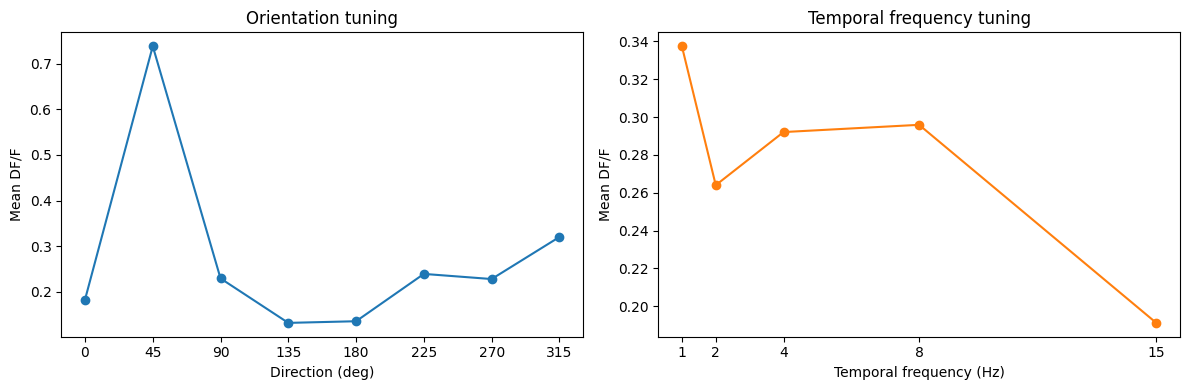

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(orientations[:-1], dg_tuning_curves[cell_index], 'o-')
ax1.set_xlabel("Direction (deg)")
ax1.set_ylabel("Mean DF/F")
ax1.set_title("Orientation tuning")
ax1.set_xticks(orientations[:-1])

ax2.plot(temporal_frequencies[:-1], tf_tuning_curves[cell_index], 'o-', color='tab:orange')
ax2.set_xlabel("Temporal frequency (Hz)")
ax2.set_ylabel("Mean DF/F")
ax2.set_title("Temporal frequency tuning")
ax2.set_xticks(temporal_frequencies[:-1])

plt.tight_layout()
plt.show()

> **Note on combining the two stimulus dimensions:** we also tried decoding a single *joint*
> label (orientation **and** temporal frequency together, e.g. `"45.0_2.0"`). With 8 orientations
> x 5 frequencies that's 40 classes, so each class only gets a handful of trials — classifiers
> performed very poorly on this joint target. We therefore decode orientation on its own below,
> which is the more reliable and informative target.

## Step 5 — Train/test split

In [10]:
test_index = int(0.75 * num_trials)

response_train, response_test = response[:test_index], response[test_index:]
stim_ori_train, stim_ori_test = stim_ori[:test_index], stim_ori[test_index:]

print("Train:", response_train.shape, " Test:", response_test.shape)

Train: (471, 284)  Test: (157, 284)


## Step 6 — Compare classifiers

We train several classifiers on the same population response and compare how well each one
decodes orientation on held-out trials.

In [11]:
classifiers = {
    "LDA": LDA(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Ridge Classifier": RidgeClassifier(),
    "Linear SVM": SVC(kernel='linear', random_state=42),
    "RBF SVM": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
}

results = {}
for name, clf in classifiers.items():
    clf.fit(response_train, stim_ori_train)
    train_acc = accuracy_score(stim_ori_train, clf.predict(response_train))
    test_acc = accuracy_score(stim_ori_test, clf.predict(response_test))
    results[name] = {"Train Accuracy": train_acc, "Test Accuracy": test_acc}
    print(f"{name:<20} train={train_acc:.3f}  test={test_acc:.3f}")

LDA                  train=0.996  test=0.586
Logistic Regression  train=0.794  test=0.586
Ridge Classifier     train=0.902  test=0.707
Linear SVM           train=0.798  test=0.541
RBF SVM              train=0.786  test=0.516
Random Forest        train=1.000  test=0.796
KNN                  train=0.571  test=0.268
Naive Bayes          train=0.934  test=0.586


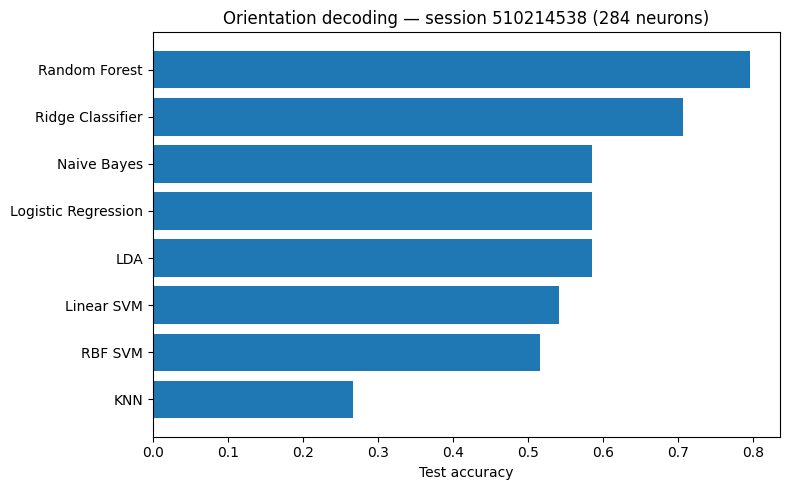

In [12]:
results_df = pd.DataFrame(results).T.sort_values("Test Accuracy", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(results_df.index, results_df["Test Accuracy"], color='tab:blue')
plt.xlabel("Test accuracy")
plt.title(f"Orientation decoding — session {session_id} ({num_neurons} neurons)")
plt.tight_layout()
plt.show()

### Best model and its confusion matrix

Best classifier: Random Forest (test accuracy = 0.796)


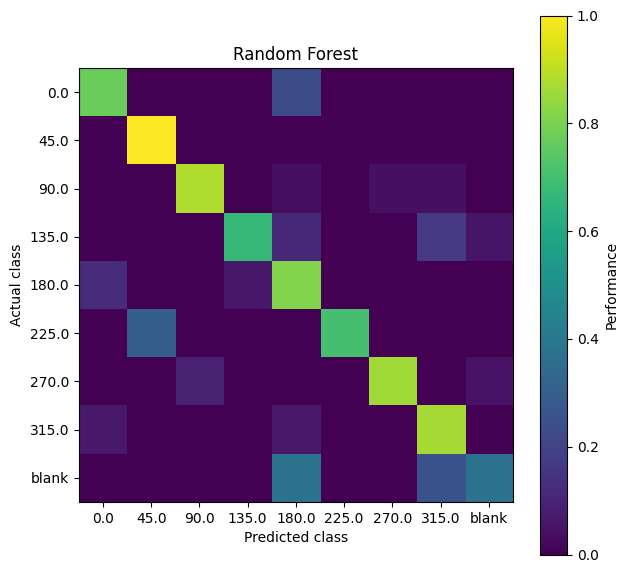

In [13]:
best_name = results_df["Test Accuracy"].idxmax()
best_model = classifiers[best_name]
print(f"Best classifier: {best_name} (test accuracy = {results[best_name]['Test Accuracy']:.3f})")

orientation_labels = [str(ori) for ori in orientations[:-1]] + ['blank']

def plot_confusion_matrix(y_test, y_pred, labels, title=None):
    C = confusion_matrix(y_test, y_pred, normalize='true', labels=labels)
    plt.figure(figsize=(7, 7))
    ax = plt.subplot(111)
    cax = ax.imshow(C, interpolation='none', vmin=0, vmax=C.max())
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('Actual class')
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    if title: ax.set_title(title)
    plt.colorbar(cax, label='Performance')
    plt.show()

best_pred = best_model.predict(response_test)
plot_confusion_matrix(stim_ori_test, best_pred, orientation_labels, title=best_name)

## Experiments

With a working population decoder in hand, we run three follow-up experiments:

1. Does decoding accuracy depend on how many neurons a session has?
2. Among the top classifiers, does the choice of classifier itself matter much?
3. Does decoding accuracy differ across visual cortical areas (VISp vs. others)?

### Experiment 1 — effect of neuron count

We take the single best classifier from Step 6 and re-run orientation decoding, from scratch, on
every session in our session list — each session has a different number of neurons.

In [14]:
def decode_orientation(session_id, model):
    """Loads one session, decodes orientation with the population, returns (n_neurons, test_acc)."""
    ds = boc.get_ophys_experiment_data(session_id)
    ts, dff_s = ds.get_dff_traces()
    st = ds.get_stimulus_table('drifting_gratings')

    resp, ori, _ = compute_stim_and_response(dff_s, st)
    n_neurons = resp.shape[1]

    ti = int(0.75 * resp.shape[0])
    X_train, X_test = resp[:ti], resp[ti:]
    y_train, y_test = ori[:ti], ori[ti:]

    clf = clone(model)
    clf.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    return n_neurons, test_acc

In [15]:
exp1_rows = []
for sid in session_ids:
    n_neurons, test_acc = decode_orientation(sid, best_model)
    exp1_rows.append({"session_id": sid, "n_neurons": n_neurons, "test_acc": test_acc})
    print(f"Session {sid}: {n_neurons} neurons -> test accuracy = {test_acc:.3f}")

exp1_df = pd.DataFrame(exp1_rows)

Session 510214538: 284 neurons -> test accuracy = 0.796
Session 644026238: 240 neurons -> test accuracy = 0.720
Session 587344053: 237 neurons -> test accuracy = 0.873
Session 590168385: 157 neurons -> test accuracy = 0.943
Session 531348161: 171 neurons -> test accuracy = 0.930
Session 501729039: 227 neurons -> test accuracy = 0.898
Session 512270518: 90 neurons -> test accuracy = 0.669
Session 527048992: 211 neurons -> test accuracy = 0.924


#Interpretation
Across the eight Rorb-IRES2-Cre VISp sessions, decoding accuracy did not increase monotonically with the number of recorded neurons. Although the session with the fewest neurons (90) achieved the lowest accuracy (66.9%), the highest accuracies (93–94%) were obtained from sessions containing approximately 150–210 neurons rather than the largest sessions (>230 neurons). This suggests that decoding performance depends not only on the number of neurons available but also on the informativeness and quality of the neural population recorded.

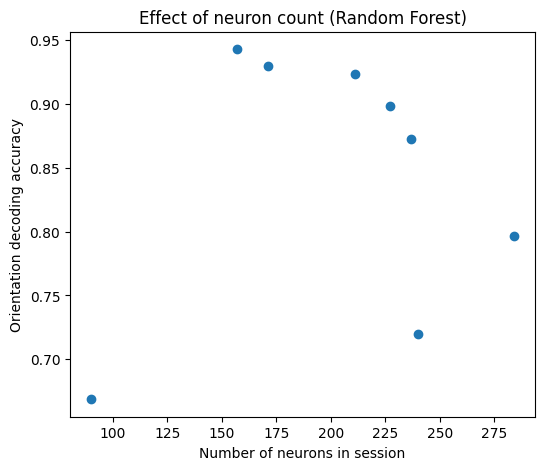

In [16]:
plt.figure(figsize=(6, 5))
plt.scatter(exp1_df["n_neurons"], exp1_df["test_acc"])
plt.xlabel("Number of neurons in session")
plt.ylabel("Orientation decoding accuracy")
plt.title(f"Effect of neuron count ({best_name})")
plt.show()

### Experiment 2 — do the top classifiers agree?

Using the results from Step 6 on our highest-neuron session, we pull out the top 5 classifiers
and compare them directly, to see whether the choice among strong classifiers matters much.

The next cell will take some minutes to run. This is because we're checking the classifiers now for all the 8 session, so for 5 classifiers, that will be 40 complete session loads

In [17]:
import pandas as pd

# Compare only the best-performing classifiers
comparison_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Ridge": RidgeClassifier(),
    "Naive Bayes": GaussianNB(),
    "LDA": LDA()
}

comparison_rows = []

for sid in session_ids:

    row = {"Session ID": sid}

    for model_name, model in comparison_models.items():

        n_neurons, test_acc = decode_orientation(sid, model)

        row["Number of Neurons"] = n_neurons
        row[model_name] = test_acc

    comparison_rows.append(row)

comparison_df = (
    pd.DataFrame(comparison_rows)
      .sort_values("Number of Neurons", ascending=False)
      .reset_index(drop=True)
)

comparison_df

,Session ID,Number of Neurons,Random Forest,Logistic Regression,Ridge,Naive Bayes,LDA
0,510214538,284,0.796178,0.585987,0.707006,0.585987,0.585987
1,644026238,240,0.719745,0.598726,0.643312,0.592357,0.585987
2,587344053,237,0.872611,0.777070,0.898089,0.713376,0.808917
3,501729039,227,0.898089,0.808917,0.898089,0.821656,0.770701
4,527048992,211,0.923567,0.802548,0.834395,0.770701,0.757962
5,531348161,171,0.929936,0.745223,0.802548,0.726115,0.738854
6,590168385,157,0.942675,0.789809,0.821656,0.834395,0.802548
7,512270518,90,0.668790,0.458599,0.560510,0.554140,0.592357


### Experiment 3 — does the visual area matter?

We repeat the same decoding pipeline, with our best classifier, on sessions from several visual
cortical areas (VISp plus a few others) and compare accuracy across areas.

In [18]:
region_targets = ['VISp', 'VISl', 'VISal', 'VISpm', 'VISam', 'VISrl']
sessions_per_region = 3

def get_sessions_for_area(area, cre_line='Rorb-IRES2-Cre', n=3):
    exps = boc.get_ophys_experiments(stimuli=['drifting_gratings'],
                                      targeted_structures=[area],
                                      cre_lines=[cre_line])
    return [exp['id'] for exp in exps[:n]]

exp3_rows = []
for area in region_targets:
    for sid in get_sessions_for_area(area, n=sessions_per_region):
        n_neurons, test_acc = decode_orientation(sid, best_model)
        exp3_rows.append({"area": area, "session_id": sid, "n_neurons": n_neurons, "test_acc": test_acc})
        print(f"{area} | session {sid}: {n_neurons} neurons -> test accuracy = {test_acc:.3f}")

exp3_df = pd.DataFrame(exp3_rows)

VISp | session 510214538: 284 neurons -> test accuracy = 0.796
VISp | session 644026238: 240 neurons -> test accuracy = 0.720
VISp | session 587344053: 237 neurons -> test accuracy = 0.873
VISl | session 546641574: 191 neurons -> test accuracy = 0.618
VISl | session 507129766: 52 neurons -> test accuracy = 0.439
VISl | session 654532828: 95 neurons -> test accuracy = 0.592
VISal | session 510390912: 87 neurons -> test accuracy = 0.503
VISal | session 504853580: 126 neurons -> test accuracy = 0.516
VISal | session 591460070: 207 neurons -> test accuracy = 0.860
VISpm | session 551888519: 170 neurons -> test accuracy = 0.427
VISpm | session 569896493: 43 neurons -> test accuracy = 0.350
VISpm | session 587339481: 79 neurons -> test accuracy = 0.548
VISam | session 569457162: 36 neurons -> test accuracy = 0.166
VISam | session 551834174: 50 neurons -> test accuracy = 0.242
VISam | session 611638995: 93 neurons -> test accuracy = 0.325
VISrl | session 640198011: 261 neurons -> test accurac

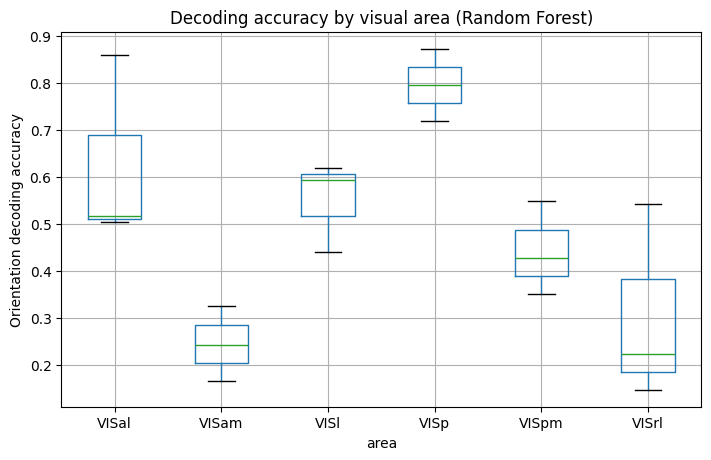

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
exp3_df.boxplot(column="test_acc", by="area", ax=ax)
ax.set_ylabel("Orientation decoding accuracy")
ax.set_title(f"Decoding accuracy by visual area ({best_name})")
plt.suptitle("")
plt.show()

## Wrap-up

- **Neuron count:** see the Experiment 1 scatter plot — does accuracy rise with more neurons, or not?
- **Classifier choice:** see Experiment 2 — do the top classifiers give the same results for all the sessions?
- **Visual area:** see the Experiment 3 boxplot — how far is VISp decoded than the other areas tested?

Let's fill the interpretation